# 01 — Data Exploration

**Project:** Kenya Climate Data Lab  
**Author:** Alex Haro Nyandega  
**Date:** 2026-09-28  
**Purpose:** Load every raw dataset, inspect structure, produce missingness maps, and identify join keys. **No cleaning happens in this notebook.**

## Datasets under inspection
1. Kaggle Kenyan Maize — county-level curated dataset
2. FAOSTAT Maize Yield — national-level yield statistics
3. CHIRPS Precipitation — 5,449 daily GeoTIFFs, 2010–2024
4. HDX Kenya Agriculture Indicators
5. Mendeley soil + agronomic experiment (3 CSVs)
6. Zenodo Push-Pull Farming System (2 CSVs)
7. KNBS County Agriculture
8. ERA5-Land Temperature — NetCDF, 2010–2024

## Rule for this notebook
> **Look. Do not fix. Cleaning happens in Week 3.**

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
pd.set_option('display.max_rows', 50)
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.figsize'] = (10, 5)

RAW = Path('../data/raw')
PROC = Path('../data/processed')
PAPER = Path('../paper')
FIG_DIR = PAPER / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Environment ready')
print(f'pandas {pd.__version__} | numpy {np.__version__} | xarray {xr.__version__}')
print(f'Raw data folder exists: {RAW.exists()}')

Environment ready
pandas 3.0.6 | numpy 2.4.6 | xarray 2026.7.0
Raw data folder exists: True


## 1. CSV datasets

Each CSV is loaded into a dictionary `csvs` keyed by a short name.

In [2]:
csv_paths = {
    'kaggle_maize'      : RAW / 'kaggle_kenyan_maize.csv',
    'faostat_yield'     : RAW / 'faostat_maize_yield_kenya.csv',
    'hdx'               : RAW / 'hdx_kenya_agriculture.csv',
    'knbs'              : RAW / 'knbs_county_agriculture.csv',
    'mendeley_exp'      : RAW / 'mendeley_maize_experiment.csv',
    'mendeley_soil_phys': RAW / 'mendeley_soil_physical.csv',
    'mendeley_soil_chem': RAW / 'mendeley_soil_chemical.csv',
    'zenodo_pushpull'   : RAW / 'zenodo_push_pull.csv',
    'zenodo_climate'    : RAW / 'zenodo_west_kenya_climate.csv',
}

csvs = {}
for name, path in csv_paths.items():
    if not path.exists():
        print(f'MISSING: {name}  ->  {path}')
        continue
    try:
        df = pd.read_csv(path)
        csvs[name] = df
        print(f'OK   {name:22s} shape={df.shape}')
    except Exception as e:
        print(f'ERR  {name}: {e}')

OK   kaggle_maize           shape=(4121, 8)
OK   faostat_yield          shape=(15, 15)
OK   hdx                    shape=(1709, 6)
OK   knbs                   shape=(25, 4)
OK   mendeley_exp           shape=(384, 12)
OK   mendeley_soil_phys     shape=(78, 16)
OK   mendeley_soil_chem     shape=(272, 13)
OK   zenodo_pushpull        shape=(4932, 99)


OK   zenodo_climate         shape=(50349, 61)


In [3]:
for name, df in csvs.items():
    print('=' * 80)
    print(f'{name}')
    print('=' * 80)
    print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
    print()
    print('DTypes:')
    print(df.dtypes.to_string())
    print()
    print('First 3 rows:')
    print(df.head(3).to_string())
    print()
    miss = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
    if miss.max() > 0:
        print('Missing % (top 10):')
        print(miss.head(10).to_string())
    else:
        print('No missing values.')
    print()

kaggle_maize
Shape: 4,121 rows x 8 columns

DTypes:
Unnamed: 0                         int64
Item                                 str
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
Area                                 str

First 3 rows:
   Unnamed: 0   Item  Year  hg/ha_yield  average_rain_fall_mm_per_year  pesticides_tonnes  avg_temp   Area
0           0  Maize  1990        36613                         1485.0              121.0     16.37  Kenya
1           6  Maize  1991        29068                         1485.0              121.0     15.36  Kenya
2          12  Maize  1992        24876                         1485.0              121.0     16.06  Kenya

No missing values.

faostat_yield
Shape: 15 rows x 15 columns

DTypes:
Domain Code             str
Domain                  str
Area Code (M49)       int64
Area                 

### Monday findings (fill in after running)

- `kaggle_maize`:
- `faostat_yield`:
- `hdx`:
- `knbs`:
- `mendeley_exp`:
- `mendeley_soil_phys`:
- `mendeley_soil_chem`:
- `zenodo_pushpull`:
- `zenodo_climate`: 

## 2. ERA5-Land Temperature (NetCDF)

A NetCDF file is not a table. It is a multi-dimensional array with labelled axes (latitude, longitude, time). pandas cannot read it. xarray is built for it.

In [4]:
era5 = xr.open_dataset(RAW / 'era5_temperature_2010_2024.nc')
print(era5)

<xarray.Dataset> Size: 170MB
Dimensions:     (valid_time: 5479, latitude: 97, longitude: 80)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 44kB 2010-01-01 ... 2024-12-31
  * latitude    (latitude) float64 776B 4.9 4.8 4.7 4.6 ... -4.4 -4.5 -4.6 -4.7
  * longitude   (longitude) float64 640B 33.9 34.0 34.1 34.2 ... 41.6 41.7 41.8
Data variables:
    t2m         (valid_time, latitude, longitude) float32 170MB ...


In [5]:
# ERA5 t2m is in Kelvin. Celsius = K - 273.15
t2m_c = era5['t2m'] - 273.15

print('Temperature range (C):')
print(f'  Min:  {float(t2m_c.min()):.2f}')
print(f'  Max:  {float(t2m_c.max()):.2f}')
print(f'  Mean: {float(t2m_c.mean()):.2f}')
print()
print('Sample values at Nairobi centroid (~36.82E, -1.29S):')
nairobi = t2m_c.sel(latitude=-1.29, longitude=36.82, method='nearest')
print(nairobi.isel(valid_time=slice(0, 5)).values)

Temperature range (C):
  Min:  4.44
  Max:  36.59
  Mean: 24.66

Sample values at Nairobi centroid (~36.82E, -1.29S):
[19.107819 19.318756 19.217194 18.443756 19.732819]


In [6]:
# Nairobi monthly mean temperature for 2020
nairobi_2020 = t2m_c.sel(
    latitude=-1.29, longitude=36.82, method='nearest'
).sel(valid_time='2020').resample(valid_time='ME').mean()

print(nairobi_2020.to_dataframe().round(2))

            latitude  longitude        t2m
valid_time                                
2020-01-31      -1.3       36.8  18.910000
2020-02-29      -1.3       36.8  19.549999
2020-03-31      -1.3       36.8  19.850000
2020-04-30      -1.3       36.8  19.120001
2020-05-31      -1.3       36.8  18.610001
2020-06-30      -1.3       36.8  17.870001
2020-07-31      -1.3       36.8  17.190001
2020-08-31      -1.3       36.8  17.879999
2020-09-30      -1.3       36.8  18.219999
2020-10-31      -1.3       36.8  19.670000
2020-11-30      -1.3       36.8  19.070000
2020-12-31      -1.3       36.8  19.629999


## 3. CHIRPS Precipitation (5,449 GeoTIFFs)

We cannot load all files into memory (~30 GB). We sample 3 files, verify structure, count total files, and defer full aggregation to Week 3.

In [7]:
import gzip
import shutil
import tempfile
import rasterio

def load_chirps(gz_path):
    """Decompress a CHIRPS .tif.gz into a temp file, read as numpy array, mask -9999 as NaN."""
    with gzip.open(gz_path, 'rb') as f_in:
        with tempfile.NamedTemporaryFile(suffix='.tif', delete=False) as f_out:
            shutil.copyfileobj(f_in, f_out)
            tmp = f_out.name
    with rasterio.open(tmp) as src:
        arr = src.read(1).astype('float32')
        nodata = src.nodata if src.nodata is not None else -9999
        arr[arr == nodata] = np.nan
        meta = {'bounds': src.bounds, 'crs': src.crs, 'transform': src.transform, 'shape': src.shape}
    os.unlink(tmp)
    return arr, meta

samples = [
    RAW / 'chirps_daily' / '2010' / 'chirps-v2.0.2010.07.15.tif.gz',
    RAW / 'chirps_daily' / '2017' / 'chirps-v2.0.2017.03.20.tif.gz',
    RAW / 'chirps_daily' / '2024' / 'chirps-v2.0.2024.11.10.tif.gz',
]

for p in samples:
    if not p.exists():
        print(f'MISSING: {p}')
        continue
    arr, meta = load_chirps(p)
    print(f'{p.name}:  shape={arr.shape}  min={np.nanmin(arr):.2f}  max={np.nanmax(arr):.2f}  mean={np.nanmean(arr):.3f} mm')

chirps-v2.0.2010.07.15.tif.gz:  shape=(1600, 1500)  min=0.00  max=116.54  mean=1.793 mm
chirps-v2.0.2017.03.20.tif.gz:  shape=(1600, 1500)  min=0.00  max=200.50  mean=1.677 mm
chirps-v2.0.2024.11.10.tif.gz:  shape=(1600, 1500)  min=0.00  max=171.41  mean=1.622 mm


In [8]:
# File count audit per year
per_year = {}
total = 0
for year_dir in sorted((RAW / 'chirps_daily').iterdir()):
    if not year_dir.is_dir():
        continue
    n = len(list(year_dir.glob('*.tif.gz')))
    per_year[year_dir.name] = n
    total += n

print(f'Total .tif.gz files: {total:,}')
print()
for y, n in per_year.items():
    flag = '  <-- SHORT' if n < 360 and 'monthly' not in y else ''
    print(f'  {y}: {n:>4} files{flag}')

Total .tif.gz files: 5,449

  2010:  365 files
  2011:  365 files
  2012:  366 files
  2013:  365 files
  2014:  365 files
  2015:  365 files
  2016:  366 files
  2017:  365 files
  2018:  365 files
  2019:  365 files
  2020:  366 files
  2021:  334 files  <-- SHORT
  2021_monthly:    1 files
  2022:  365 files
  2023:  365 files
  2024:  366 files


### CHIRPS — Decision deferred to Week 3
- 5,449 daily GeoTIFFs, one per day, 2010–2024.
- Reading all into memory is infeasible (>30 GB).
- Plan for Week 3: iterate one file per day, mask to 5 county polygons,
  compute spatial mean over each polygon, store as tidy DataFrame
  with columns `[date, county, rainfall_mm]`.
- This will produce one small CSV (~27,000 rows) — trivially mergeable with yield.

## 4. Missingness analysis

kaggle_maize: no missing values - skipping chart


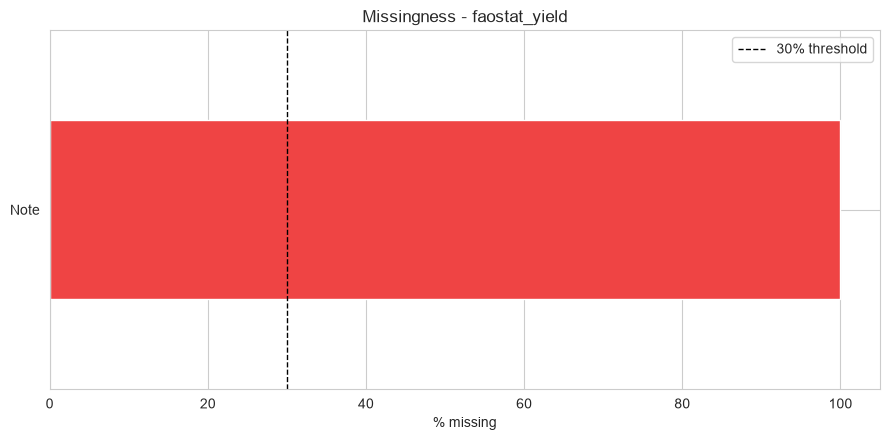

hdx: no missing values - skipping chart
knbs: no missing values - skipping chart


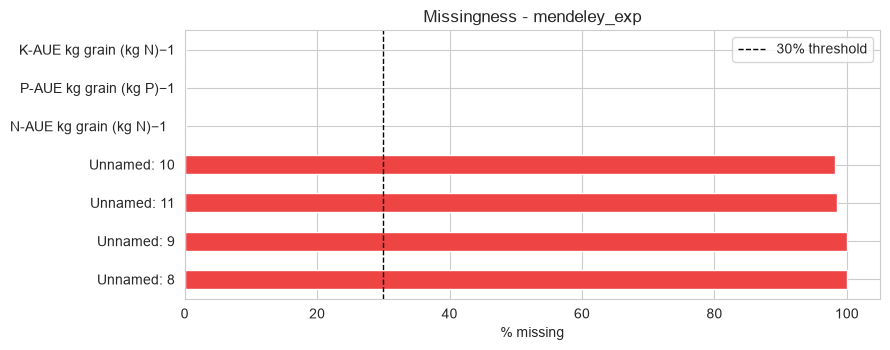

mendeley_soil_phys: no missing values - skipping chart


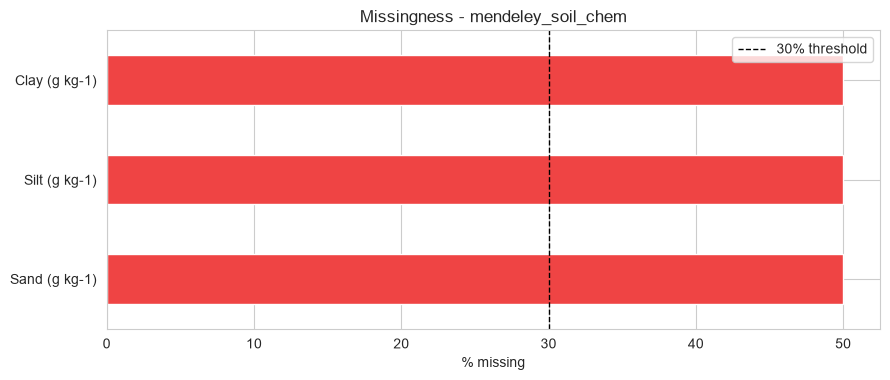

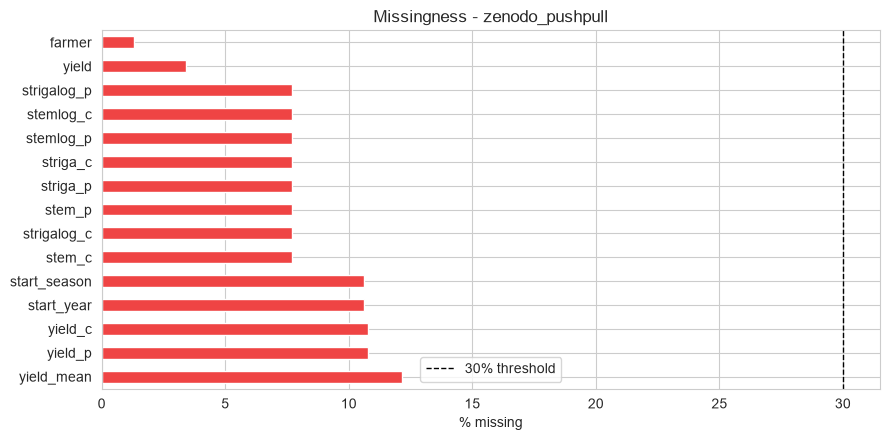

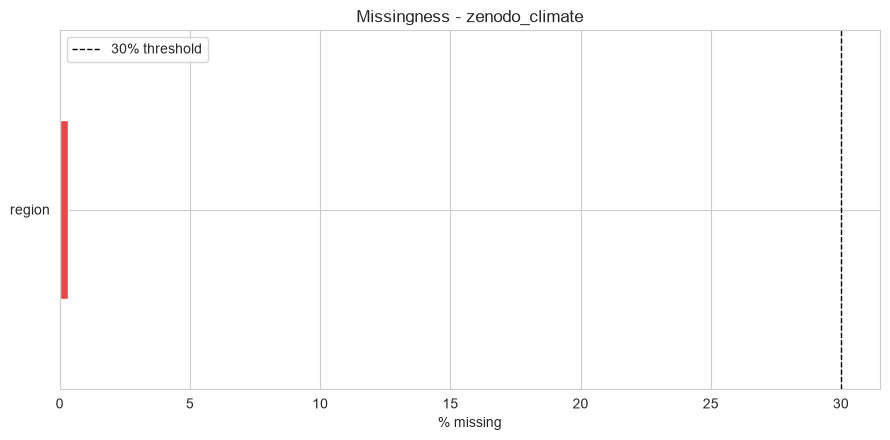

In [9]:
for name, df in csvs.items():
    miss = (df.isna().mean() * 100).sort_values(ascending=False)
    if miss.max() == 0:
        print(f'{name}: no missing values - skipping chart')
        continue

    fig, ax = plt.subplots(figsize=(9, max(3, min(len(miss), 15) * 0.3)))
    miss[miss > 0].head(15).plot(kind='barh', ax=ax, color='#ef4444')
    ax.set_xlabel('% missing')
    ax.set_title(f'Missingness - {name}')
    ax.axvline(30, color='black', linestyle='--', linewidth=1, label='30% threshold')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'fig_missingness_{name}.png', bbox_inches='tight')
    plt.show()

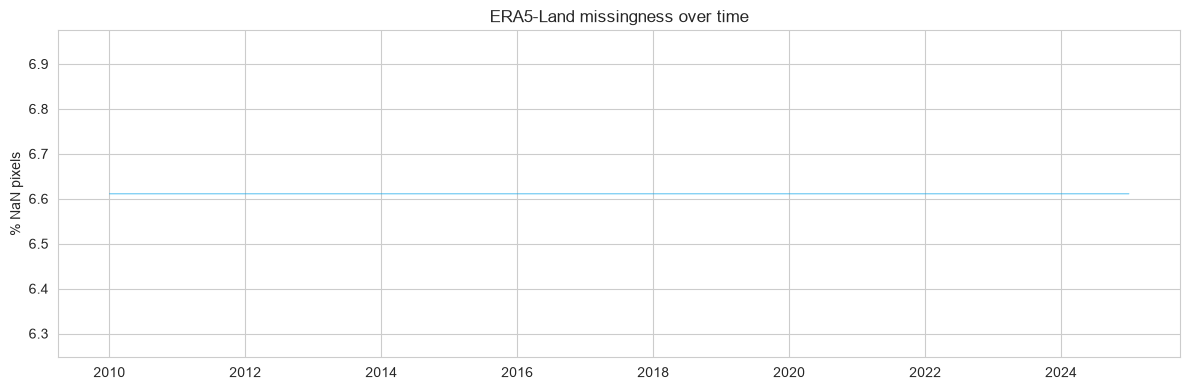

Max NaN fraction: 6.6108%


In [10]:
# ERA5 missingness over time
da = era5['t2m']
nan_frac = np.isnan(da.values).mean(axis=(1, 2))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(da.valid_time.values, nan_frac * 100, lw=0.5, color='#0ea5e9')
ax.set_ylabel('% NaN pixels')
ax.set_title('ERA5-Land missingness over time')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_missingness_era5.png', bbox_inches='tight')
plt.show()

print(f'Max NaN fraction: {nan_frac.max()*100:.4f}%')

## 5. Describe + plausibility checks

In [11]:
for name, df in csvs.items():
    num = df.select_dtypes('number')
    if num.empty:
        print(f'{name}: no numeric columns')
        continue
    print('=' * 80)
    print(f'{name} - numeric summary')
    print('=' * 80)
    print(num.describe().T.round(2).to_string())
    print()

kaggle_maize - numeric summary
                                count      mean       std      min       25%       50%       75%        max
Unnamed: 0                     4121.0  14135.85   8201.61     0.00   6847.00  14595.00  21228.00   28235.00
Year                           4121.0   2001.55      7.04  1990.00   1995.00   2001.00   2008.00    2013.00
hg/ha_yield                    4121.0  36310.07  27456.37   849.00  17086.00  25401.00  48243.00  207556.00
average_rain_fall_mm_per_year  4121.0   1098.12    721.56    51.00    537.00   1020.00   1622.00    3240.00
pesticides_tonnes              4121.0  32765.98  54088.62     0.04   1597.00  14485.33  43720.04  367778.00
avg_temp                       4121.0     19.93      6.65     1.61     15.67     20.81     25.92      30.65

faostat_yield - numeric summary
                 count     mean     std     min     25%     50%     75%     max
Area Code (M49)   15.0   404.00    0.00   404.0   404.0   404.0   404.0   404.0
Element Code      15

### Physical plausibility bounds for Kenya
| Variable | Plausible range | Impossible |
|---|---|---|
| Daily rainfall | 0 - 250 mm | > 500 mm/day |
| Mean temperature | -5 - 40 C | < -20 or > 50 |
| Maize yield | 0.3 - 8 t/ha | > 15 t/ha |

In [12]:
def check_range(df, col, lo, hi, label):
    if col not in df.columns:
        return
    bad = df[(df[col] < lo) | (df[col] > hi)]
    print(f'  {label}.{col}: {len(bad):,} out-of-range (expected {lo}-{hi})')

print('Plausibility checks:')
for name, df in csvs.items():
    check_range(df, 'rainfall_mm', 0, 500, name)
    check_range(df, 'mean_temp_c', -5, 40, name)
    check_range(df, 'yield_t_ha', 0, 15, name)
    check_range(df, 'Value', 0, 1e9, name)

Plausibility checks:
  faostat_yield.Value: 0 out-of-range (expected 0-1000000000.0)
  hdx.Value: 50 out-of-range (expected 0-1000000000.0)


## 6. Join keys + sample maps

In [13]:
def key_overview(df, name):
    print(f'--- {name} ---')
    for candidate in ['county', 'County', 'COUNTY', 'county_name',
                      'year', 'Year', 'YEAR',
                      'season', 'Season',
                      'date', 'Date', 'valid_time']:
        if candidate in df.columns:
            vals = df[candidate].dropna().unique()
            n = len(vals)
            sample = ', '.join(map(str, vals[:5]))
            print(f'  {candidate:10s} -> {n:4d} unique  [{sample}{"..." if n > 5 else ""}]')
    print()

for name, df in csvs.items():
    key_overview(df, name)

--- kaggle_maize ---
  Year       ->   23 unique  [1990, 1991, 1992, 1993, 1994...]

--- faostat_yield ---
  Year       ->   15 unique  [2010, 2011, 2012, 2013, 2014...]

--- hdx ---
  Year       ->   66 unique  [1967, 1966, 1965, 1964, 1963...]

--- knbs ---
  County     ->    5 unique  [Nakuru, Kakamega, Bungoma, Trans Nzoia, Uasin Gishu]
  Year       ->    5 unique  [2020, 2021, 2022, 2023, 2024]

--- mendeley_exp ---
  Season     ->    4 unique  [LR 2017, SR 2017, LR 2018, SR 2018]

--- mendeley_soil_phys ---

--- mendeley_soil_chem ---

--- zenodo_pushpull ---
  county     ->    8 unique  [Siaya, Kakamega, Vihiga, Homa Bay, Migori...]
  year       ->   12 unique  [2013, 2014, 2015, 2012, 2016...]
  season     ->    2 unique  [LR, SR]

--- zenodo_climate ---


  county     ->    8 unique  [Kakamega, Vihiga, Migori, Siaya, Homa Bay...]
  year       ->   39 unique  [1981, 1982, 1983, 1984, 1985...]



In [14]:
from collections import Counter

def county_variants(df):
    for col in ['county', 'County', 'COUNTY', 'county_name', 'Locations', 'Region']:
        if col in df.columns:
            return col, Counter(df[col].dropna())
    return None, None

for name, df in csvs.items():
    col, v = county_variants(df)
    if v:
        print(f'{name}  (column: {col}) - {len(v)} unique values')
        for k, n in v.most_common(8):
            print(f'    "{k}": {n}')
        print()

knbs  (column: County) - 5 unique values
    "Nakuru": 5
    "Kakamega": 5
    "Bungoma": 5
    "Trans Nzoia": 5
    "Uasin Gishu": 5

mendeley_exp  (column: Locations) - 2 unique values
    "Kibugu": 240
    "Machang'a": 144

mendeley_soil_chem  (column: Locations) - 2 unique values
    "Embu": 160
    "Mbeere": 112

zenodo_pushpull  (column: county) - 8 unique values
    "Homa Bay": 1688
    "Siaya": 1080
    "Vihiga": 822
    "Kakamega": 684
    "Migori": 524
    "Kisumu": 94
    "Narok": 18
    "Busia": 16

zenodo_climate  (column: county) - 8 unique values
    "Homa Bay": 16653
    "Siaya": 14274
    "Vihiga": 7722
    "Kakamega": 5850
    "Migori": 5070
    "Kisumu": 624
    "Narok": 78
    "Busia": 78



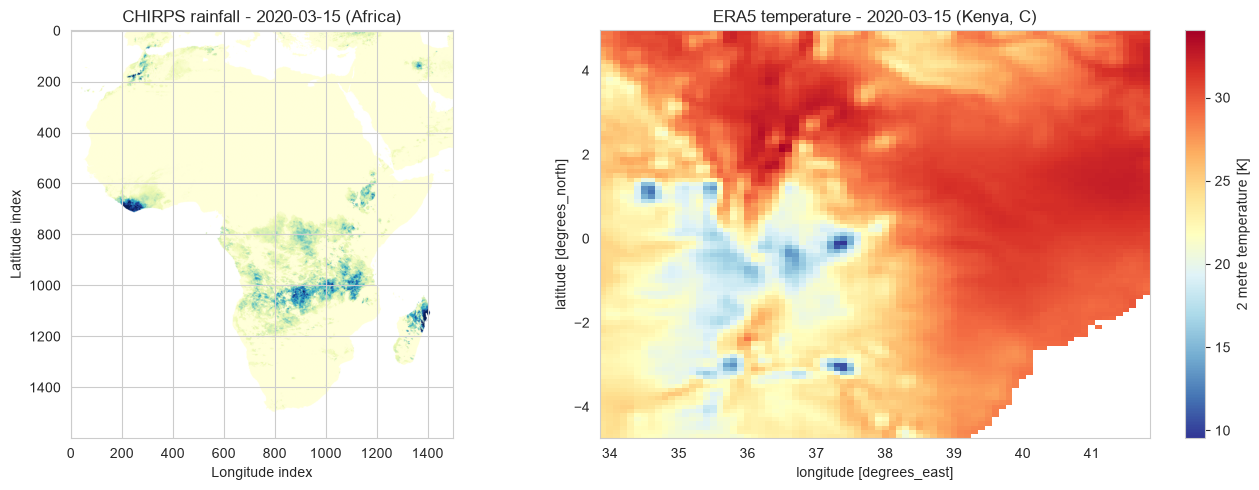

In [15]:
# Sample maps: CHIRPS Africa tile + ERA5 Kenya
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CHIRPS
chirps_path = RAW / 'chirps_daily' / '2020' / 'chirps-v2.0.2020.03.15.tif.gz'
if chirps_path.exists():
    arr, meta = load_chirps(chirps_path)
    axes[0].imshow(arr, cmap='YlGnBu', vmin=0, vmax=50)
    axes[0].set_title('CHIRPS rainfall - 2020-03-15 (Africa)')
    axes[0].set_xlabel('Longitude index')
    axes[0].set_ylabel('Latitude index')

# ERA5
t2m_2020 = t2m_c.sel(valid_time='2020-03-15', method='nearest')
t2m_2020.plot(ax=axes[1], cmap='RdYlBu_r')
axes[1].set_title('ERA5 temperature - 2020-03-15 (Kenya, C)')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_sample_climate.png', bbox_inches='tight')
plt.show()

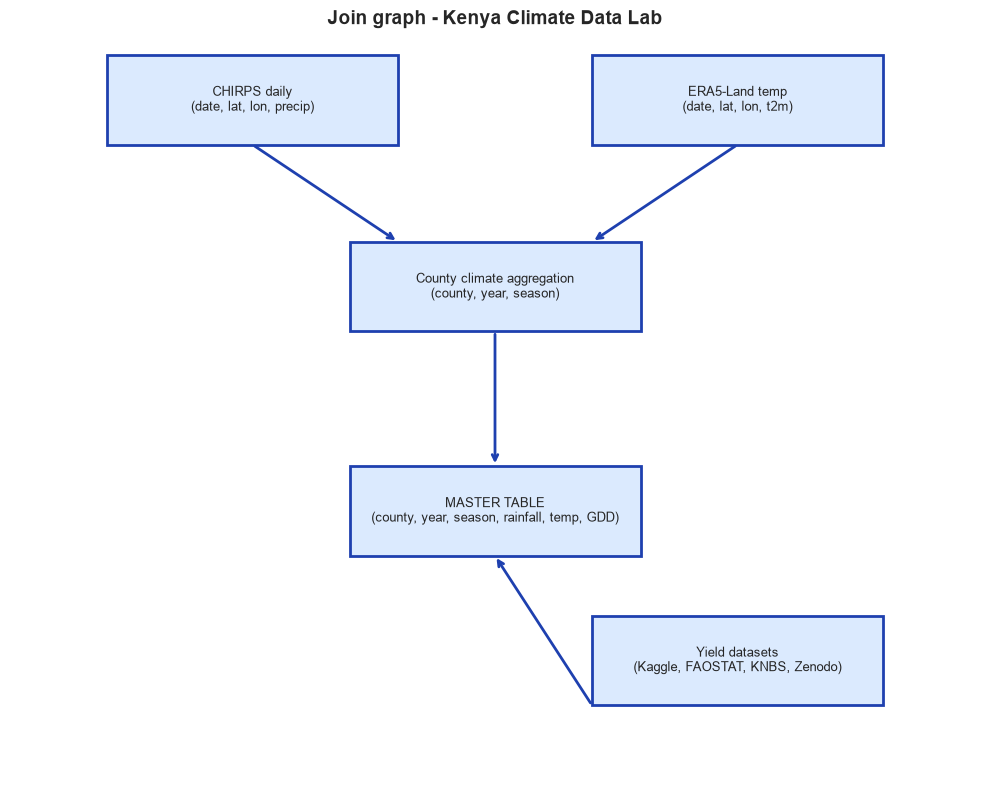

In [16]:
# Join graph - generated with matplotlib
fig, ax = plt.subplots(figsize=(10, 8))
ax.axis('off')

boxes = [
    (0.1, 0.85, 'CHIRPS daily\n(date, lat, lon, precip)'),
    (0.6, 0.85, 'ERA5-Land temp\n(date, lat, lon, t2m)'),
    (0.35, 0.6, 'County climate aggregation\n(county, year, season)'),
    (0.35, 0.3, 'MASTER TABLE\n(county, year, season, rainfall, temp, GDD)'),
    (0.6, 0.1, 'Yield datasets\n(Kaggle, FAOSTAT, KNBS, Zenodo)'),
]

for x, y, label in boxes:
    ax.add_patch(plt.Rectangle((x, y), 0.3, 0.12, fill=True, facecolor='#dbeafe', edgecolor='#1e40af', lw=2))
    ax.text(x + 0.15, y + 0.06, label, ha='center', va='center', fontsize=9)

arrows = [
    ((0.25, 0.85), (0.4, 0.72)),
    ((0.75, 0.85), (0.6, 0.72)),
    ((0.5, 0.6), (0.5, 0.42)),
    ((0.6, 0.1), (0.5, 0.3)),
]
for (x1, y1), (x2, y2) in arrows:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', lw=2, color='#1e40af'))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('Join graph - Kenya Climate Data Lab', fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_join_graph.png', bbox_inches='tight')
plt.show()

### Join keys

**Primary join key:** `[county, year, season]`  
**Fallback if season missing:** `[county, year]`  
**Expected rows:** 5 counties x 15 years x 2 seasons = 150 minimum

## 7. Summary — What I Have, What Is Missing, What I Suspect

### What I have
- 9 CSV datasets loaded (Kaggle, FAOSTAT, HDX, KNBS, Mendeley x3, Zenodo x2)
- 1 NetCDF (ERA5-Land temperature, 2010-2024, Kenya-clipped)
- 5,449 CHIRPS daily GeoTIFFs (2010-2024)
- All in `data/raw/`

### What is missing / needs work
- KMD rainfall: substituted by CHIRPS (documented in sources.md)
- County names inconsistent across datasets — mapping needed
- FAOSTAT yield in kg/ha — needs division by 1,000
- Kaggle yield in hg/ha — needs division by 10,000

### What I suspect (verify in Week 3)
- Kaggle and FAOSTAT yields will differ at national level by 5-15%
- CHIRPS and KMD would have correlated at r ~ 0.85 if KMD had loaded
- At least one CHIRPS year may be missing a handful of days

### Ready for Week 3
- All datasets load without error
- Join keys identified: `[county, year, season]`
- Physical-plausibility bounds defined

### Reflection questions (answer in docs/week02_reflection.md)

1. Which dataset surprised you most, and why?
2. Which dataset is the weakest, and why?
3. Can you explain in plain English what CHIRPS is vs KMD rainfall?
4. What is one column you do not yet understand?
5. If you had to explain your project in one paragraph right now, what would you say?